# Week 6 - Bivariate Analysis, part 2

# 1. Lesson: no lesson this week

# 2. Weekly graph question

Suppose you wanted to show the nitrate and phosphate level in a water sample.  What are the advantages and disadvantages of showing this as an area plot, as opposed to two separate line graphs?  How would you adjust the graphs shown to improve the presentation?

In [86]:
import numpy as np
import seaborn as sns
import pandas as pd

/var/folders/nz/d3kwmfmx2gjg_kjxts_1szhh0000gn/T/ipykernel_11627/2149468501.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

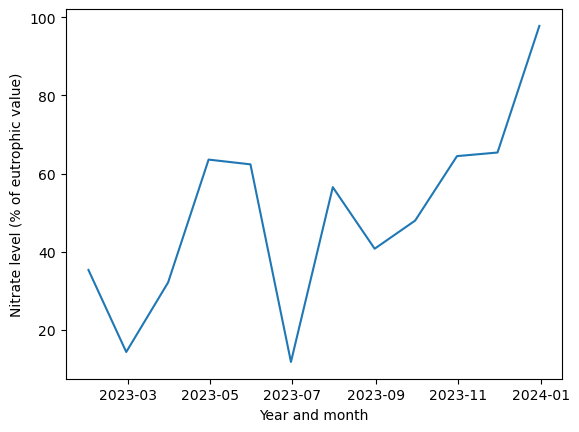

In [87]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

/var/folders/nz/d3kwmfmx2gjg_kjxts_1szhh0000gn/T/ipykernel_11627/1726504607.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

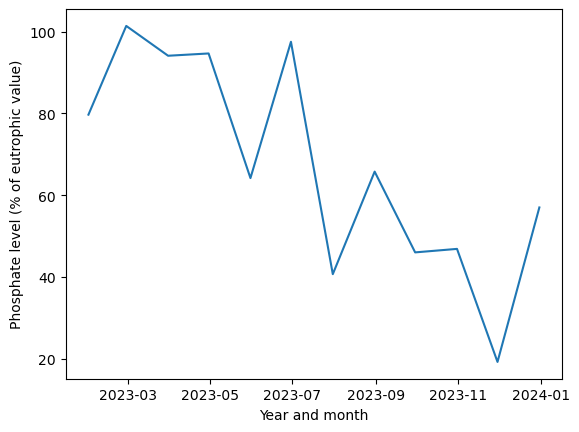

In [88]:
np.random.seed(1)
time_series_2 =  100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series_2)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

<Axes: >

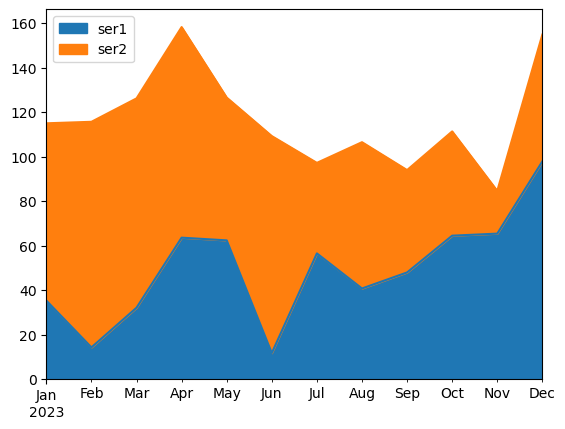

In [89]:
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area()

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Find correlations between pairs of variables.

- Draw scatterplots, especially when the correlation is large.

- Draw pairplots.

- Draw line graphs and/or area graphs when there is date or time data together with numerical data.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If the data are not useable, find some new data!

- Do you see any outliers?  (Data points that are far from the rest of the data).

- Are any data items highly correlated with each other, suggesting that they are redundant?

- For the line plots, do you see a trend or pattern over time?  Does this suggest that the data are changing over time (drifting) in such a way as to invalidate comparisons?

- Can you think of any confounding variables?  (Third variables that could explain any correlations between other variables.  These third variables may or may not be reported in the dataset.)

In [90]:
# NCHS Death Rates and Life Expectancy dataset
nchs = pd.read_csv('https://data.cdc.gov/api/views/w9j2-ggv5/rows.csv?accessType=DOWNLOAD', sep=',')
print(nchs.head(5))

   Year       Race         Sex  Average Life Expectancy (Years)  \
0  1900  All Races  Both Sexes                             47.3   
1  1901  All Races  Both Sexes                             49.1   
2  1902  All Races  Both Sexes                             51.5   
3  1903  All Races  Both Sexes                             50.5   
4  1904  All Races  Both Sexes                             47.6   

   Age-adjusted Death Rate  
0                   2518.0  
1                   2473.1  
2                   2301.3  
3                   2379.0  
4                   2502.5  


In [91]:
# Convert categorical variables to numerical
nchs_encoded = pd.get_dummies(nchs, columns=categorical_columns, drop_first=True) # use drop_first to avoid dummy variable trap

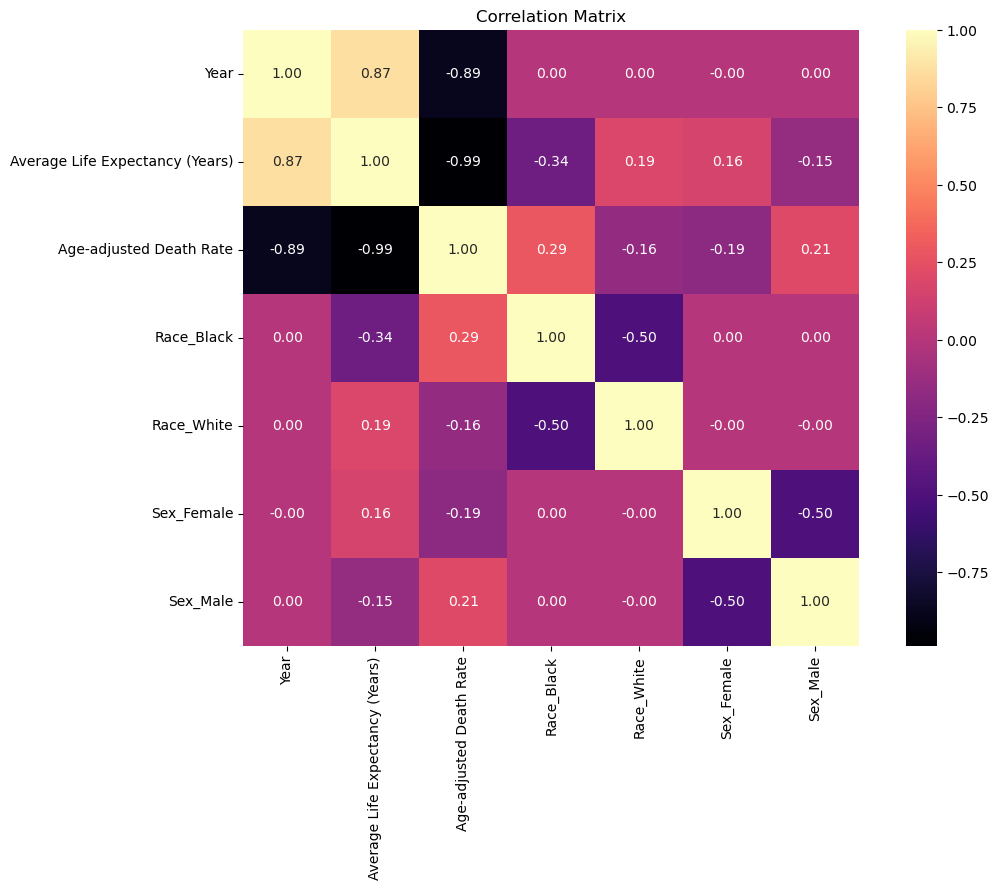

In [92]:
# Find correlations between pairs of variables
correlation_matrix = nchs_encoded.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="magma", square=True)
plt.title("Correlation Matrix")
plt.show()

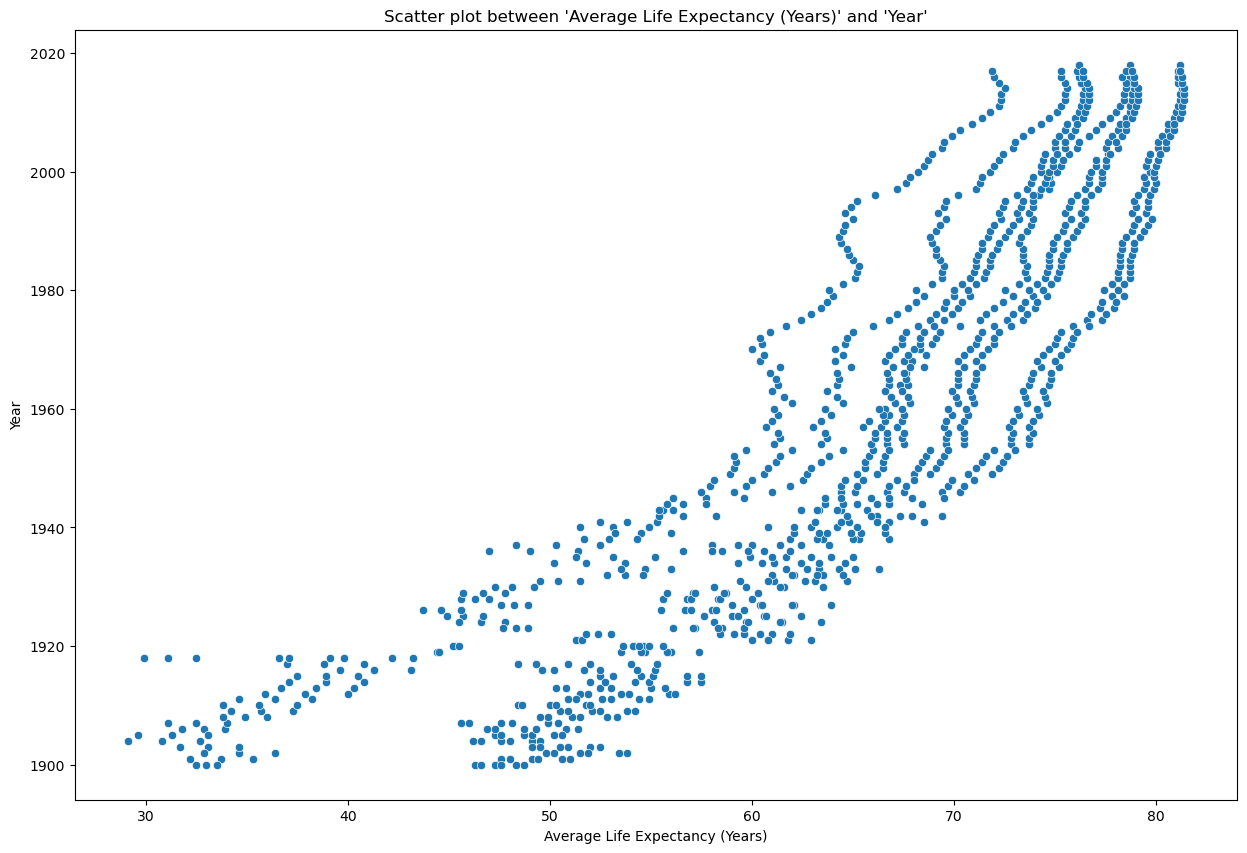

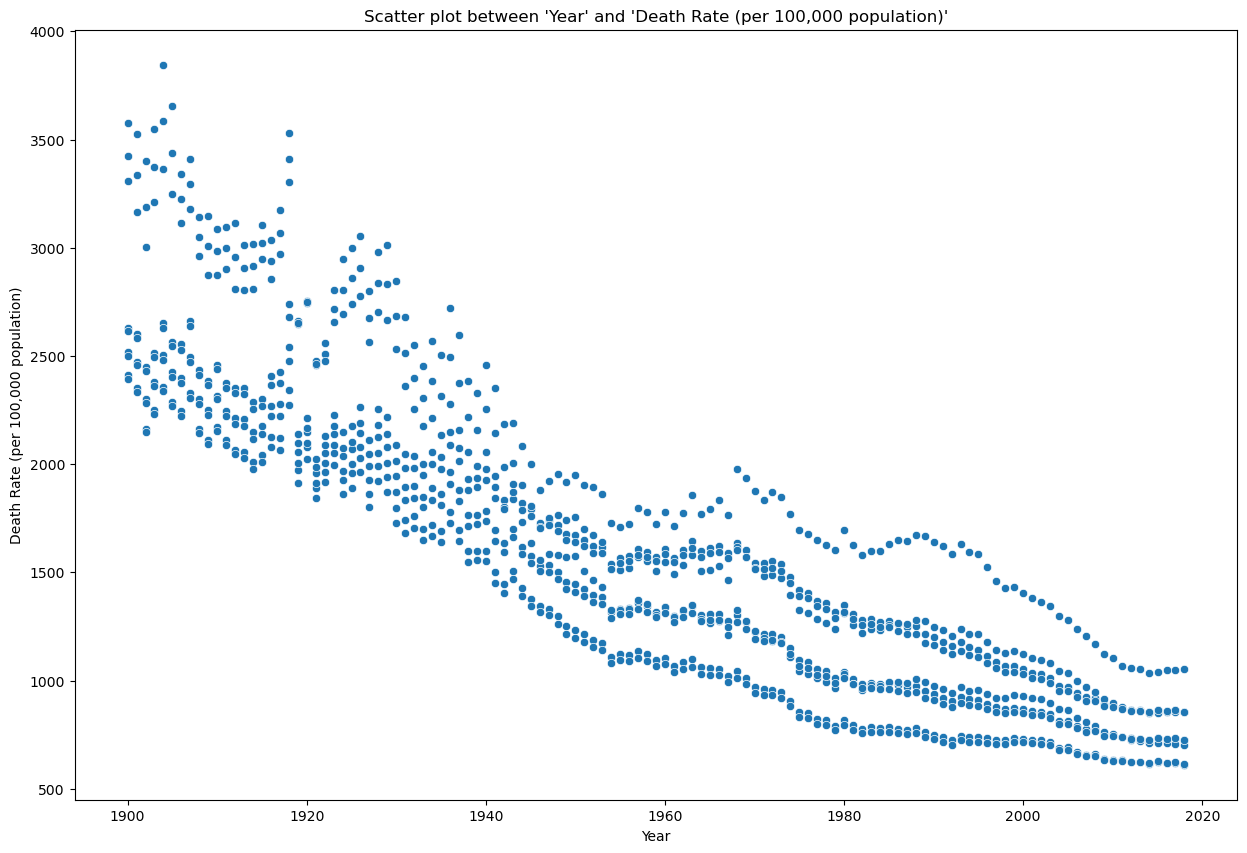

KeyError: 'Race (Black)'

In [93]:
# Scatter plots of most correlated features:

# Average Life Expectancy (Years) vs Year - highest positive correlation
plt.figure(figsize=(15, 10))
sns.scatterplot(data=nchs_encoded, x=nchs_encoded['Average Life Expectancy (Years)'], y=nchs_encoded['Year'])
plt.title(f"Scatter plot between 'Average Life Expectancy (Years)' and 'Year'")
plt.xlabel('Average Life Expectancy (Years)')
plt.ylabel('Year')
plt.show()

# Year vs Death Rate - highest negative correlation
plt.figure(figsize=(15, 10))
sns.scatterplot(data=nchs_encoded, x=nchs_encoded['Year'], y=nchs_encoded['Age-adjusted Death Rate'])
plt.title(f"Scatter plot between 'Year' and 'Death Rate (per 100,000 population)'")
plt.xlabel('Year')
plt.ylabel('Death Rate (per 100,000 population)')
plt.show()

# Year vs Death Rate (when Race = Black)
nchs_encoded_grouped = nchs_encoded[nchs_encoded['Race (Black)'] == 1]
plt.figure(figsize=(15, 10))
sns.scatterplot(data=nchs_encoded_grouped, x=nchs_encoded_grouped['Year'], y=nchs_encoded_grouped['Age-adjusted Death Rate'])
plt.title(f"Scatter plot between 'Year' and 'Death Rate (per 100,000 population)' (when Race = Black)")
plt.xlabel('Year')
plt.ylabel('Death Rate (per 100,000 population)')
plt.show()

# Year vs Death Rate (when Race = White)
nchs_encoded_grouped = nchs_encoded[nchs_encoded['Race (White)'] == 1]
plt.figure(figsize=(15, 10))
sns.scatterplot(data=nchs_encoded_grouped, x=nchs_encoded_grouped['Year'], y=nchs_encoded_grouped['Age-adjusted Death Rate'])
plt.title(f"Scatter plot between 'Year' and 'Death Rate (per 100,000 population)' (when Race = White)")
plt.xlabel('Year')
plt.ylabel('Death Rate (per 100,000 population)')

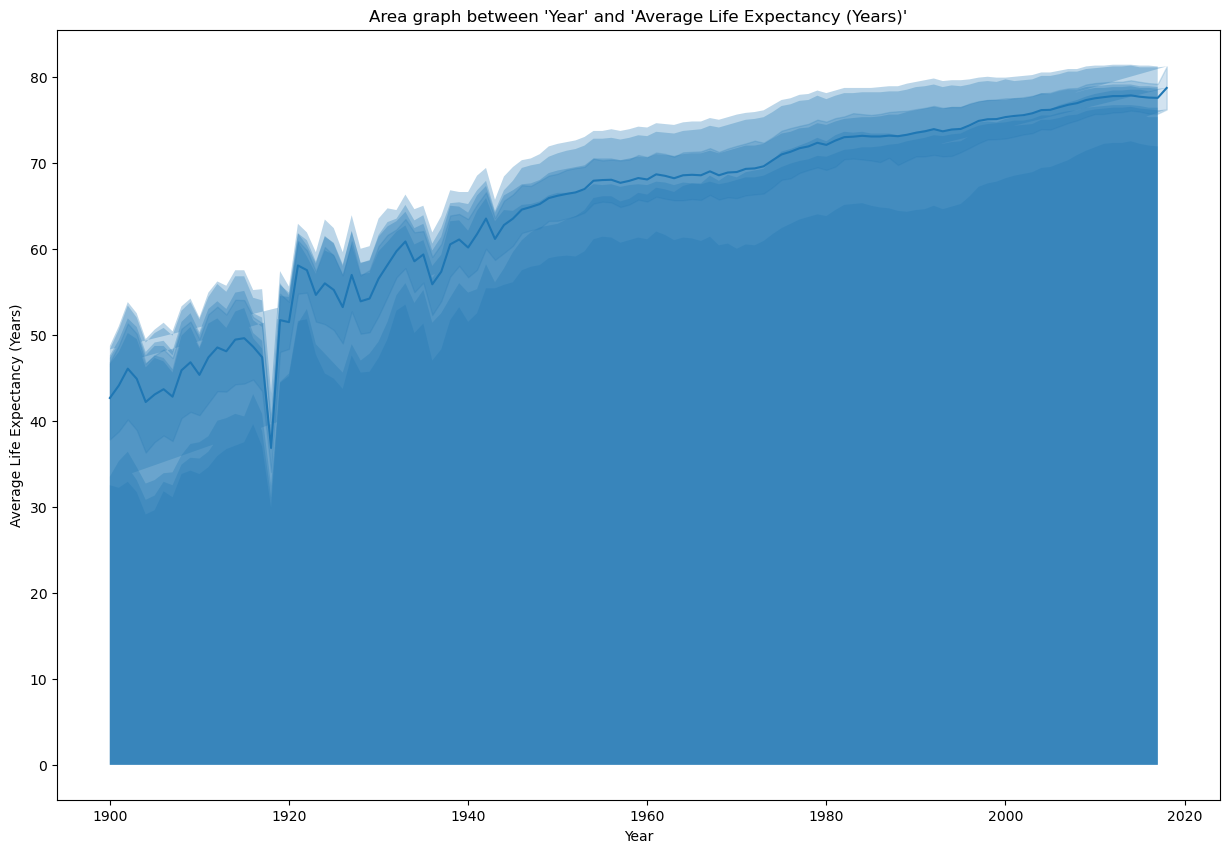

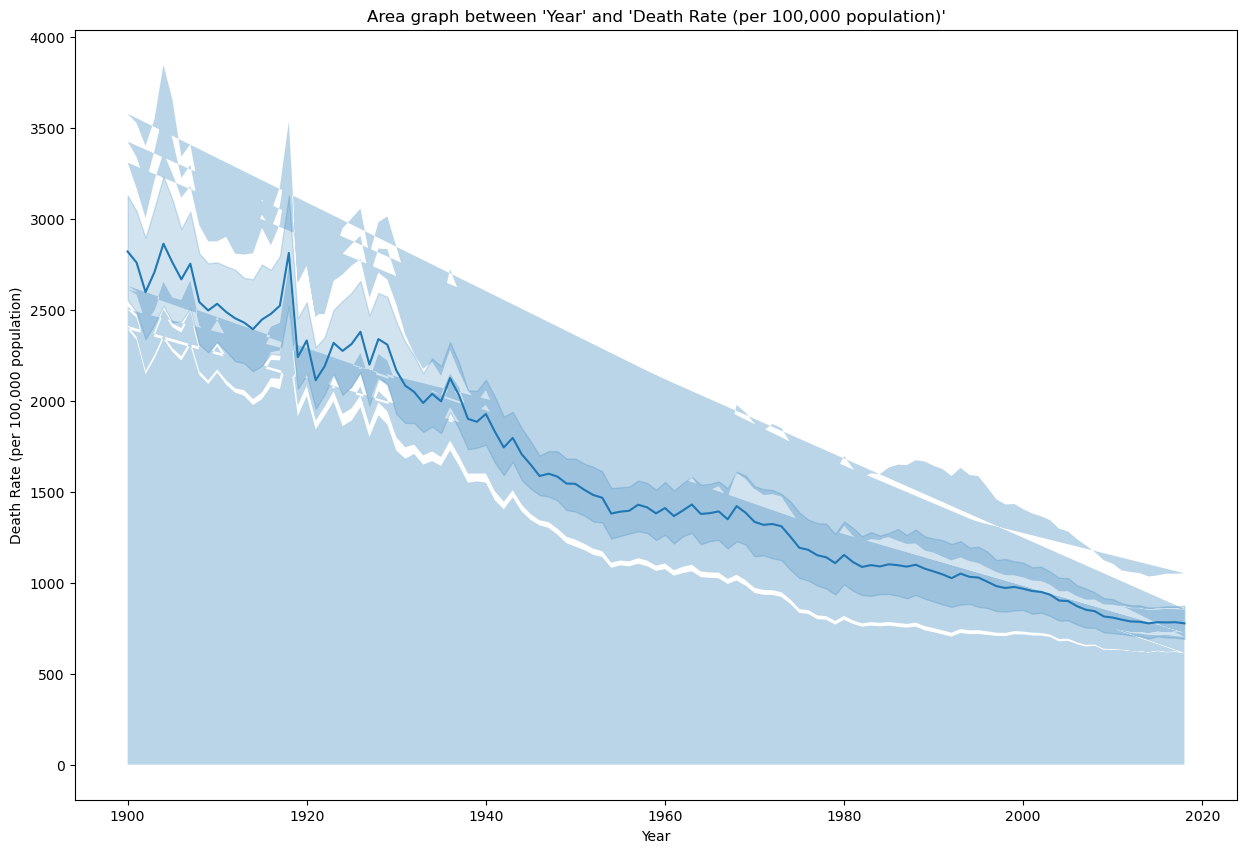

In [ ]:
# Area graphs:

# Area graph for Average Life Expectancy (Years)
plt.figure(figsize=(15, 10))
sns.lineplot(data=nchs_encoded, x=nchs_encoded['Year'], y=nchs_encoded['Average Life Expectancy (Years)'], estimator='mean')
plt.fill_between(nchs_encoded['Year'], nchs_encoded['Average Life Expectancy (Years)'], alpha=0.3)
plt.title(f"Area graph between 'Year' and 'Average Life Expectancy (Years)'")
plt.xlabel('Year')
plt.ylabel('Average Life Expectancy (Years)')
plt.show()

# Area graph for Death Rate
plt.figure(figsize=(15, 10))
sns.lineplot(data=nchs_encoded, x=nchs_encoded['Year'], y=nchs_encoded['Age-adjusted Death Rate'], estimator='mean')
plt.fill_between(nchs_encoded['Year'], nchs_encoded['Age-adjusted Death Rate'], alpha=0.3)
plt.title(f"Area graph between 'Year' and 'Death Rate (per 100,000 population)'")
plt.xlabel('Year')
plt.ylabel('Death Rate (per 100,000 population)')
plt.show()

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 86-98 of the Storytelling With Data book as best you can.  (The second half of chapter three).  You do not have to get the exact data values right, just the overall look and feel.

/var/folders/nz/d3kwmfmx2gjg_kjxts_1szhh0000gn/T/ipykernel_11627/122246321.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{int(x)}%' for x in ax.get_xticks()])


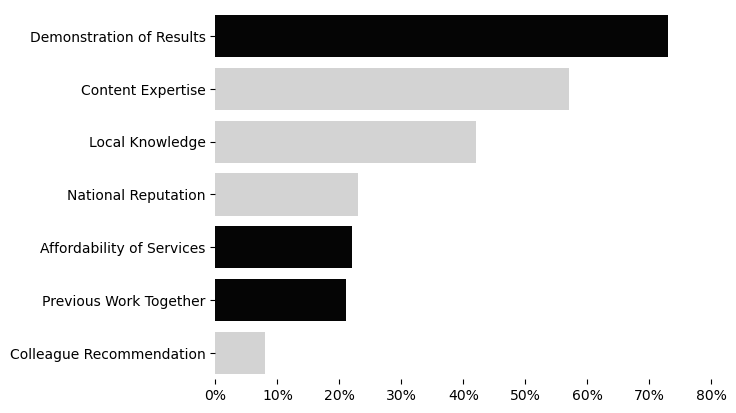

In [ ]:
# STORYTELLING WITH DATA GRAPH:

# Horizontal Bar Chart
categories =['Demonstration of Results', 'Content Expertise', 'Local Knowledge', 'National Reputation', 'Affordability of Services', 'Previous Work Together', 'Colleague Recommendation']
percentages = [73, 57, 42, 23, 22, 21, 8]

color_map = {
  'Demonstration of Results': "#050505",
  'Content Expertise':          "lightgrey",
  'Local Knowledge':            "lightgrey",
  'National Reputation':       "lightgrey",
  'Affordability of Services': "#050505",
  'Previous Work Together':    "#050505",
  'Colleague Recommendation':  "lightgrey",
}
colors = [color_map[c] for c in categories]

ax = sns.barplot(x=percentages, y=categories, color='lightgrey')  # initial plot

for spine in ax.spines.values():        # completely removes graph border 
    spine.set_visible(False)
    
for i, p in enumerate(ax.patches):      # set colors explicitly
    p.set_facecolor(colors[i])

# convert x-axis ticks to percentages
ax.set_xticklabels([f'{int(x)}%' for x in ax.get_xticks()])

plt.xlim(0, 80)
plt.show()